<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Practica_20_Practicas_sobre_normalizaci%C3%B3n_y_transformaci%C3%B3n_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #20: Practicas sobre normalización y transformación de datos
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**

# **Ejercicio 1: Normalización Min-Max**

1.	Cargar el dataset wine de sklearn.
2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


Columnas disponibles: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

=== Resumen numerico ===
Columna analizada: alcohol
Original     -> min: 11.0300, max: 14.8300, media: 13.0006
Normalizado  -> min: 0.0000, max: 1.0000, media: 0.5186
Shapiro original    -> W: 0.981804, p-valor: 0.020048 -> Rechazo normalidad (p < 0.05)
Shapiro normalizado -> W: 0.981804, p-valor: 0.020048 -> Rechazo normalidad (p < 0.05)

Nota rapida:
- Min-Max solo reescala; no corrige la normalidad.
- Por ser una transformacion lineal, Shapiro da el mismo W y p.


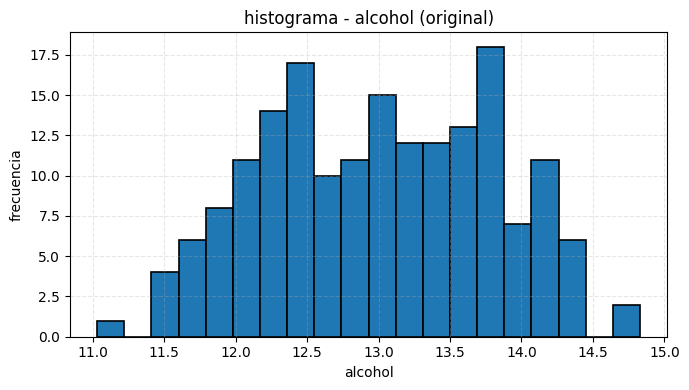

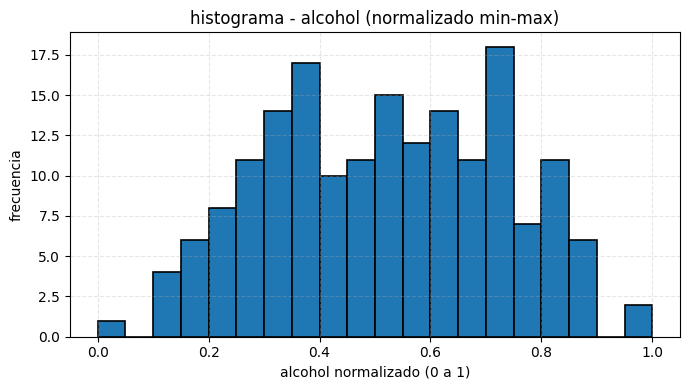

In [25]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import shapiro
import numpy as np
import matplotlib.pyplot as plt

# Cargo el dataset wine como DataFrame para poder ver columnas por nombre
datos_wine = load_wine(as_frame=True)
X = datos_wine.data   # solo caracteristicas
y = datos_wine.target # no lo uso aqui, solo lo dejo por claridad

# Muestro las columnas para decidir que variable quiero analizar
print("Columnas disponibles:", list(X.columns))

# Elijo la caracteristica numerica a analizar
columna_objetivo = "alcohol"
alcohol = X[columna_objetivo].to_numpy()  # lo paso a vector 1D

# Corro la prueba de normalidad (Shapiro-Wilk) en los datos originales
# H0: los datos provienen de una distribucion normal; si p < 0.05, rechazo H0
W_original, p_original = shapiro(alcohol)

# Aplico normalizacion Min-Max para llevar al rango [0, 1]
# Esta transformacion es lineal (afin): no cambia la forma, solo la escala
escalador = MinMaxScaler()
alcohol_norm = escalador.fit_transform(alcohol.reshape(-1, 1)).ravel()

# Corro Shapiro-Wilk en los datos ya normalizados
W_norm, p_norm = shapiro(alcohol_norm)

# Defino una funcion corta para interpretar el p-valor de forma rapida
def interpreta_p(p):
    return "Rechazo normalidad (p < 0.05)" if p < 0.05 else "No rechazo normalidad (p >= 0.05)"

# Imprimo un resumen numerico para tener todo claro de un vistazo
print("\n=== Resumen numerico ===")
print(f"Columna analizada: {columna_objetivo}")
print(f"Original     -> min: {alcohol.min():.4f}, max: {alcohol.max():.4f}, media: {alcohol.mean():.4f}")
print(f"Normalizado  -> min: {alcohol_norm.min():.4f}, max: {alcohol_norm.max():.4f}, media: {alcohol_norm.mean():.4f}")
print(f"Shapiro original    -> W: {W_original:.6f}, p-valor: {p_original:.6f} -> {interpreta_p(p_original)}")
print(f"Shapiro normalizado -> W: {W_norm:.6f}, p-valor: {p_norm:.6f} -> {interpreta_p(p_norm)}")

print("\nNota rapida:")
print("- Min-Max solo reescala; no corrige la normalidad.")
print("- Por ser una transformacion lineal, Shapiro da el mismo W y p.")

# Grafico los datos en histogramas separados y les agrego borde a las barras
# Para el borde uso edgecolor y aumento linewidth para que resalten; dejo los colores de relleno por defecto
plt.figure(figsize=(7, 4))
plt.hist(alcohol, bins=20, edgecolor='black', linewidth=1.2)
plt.title(f'histograma - {columna_objetivo} (original)')
plt.xlabel(columna_objetivo)
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(alcohol_norm, bins=20, edgecolor='black', linewidth=1.2)
plt.title(f'histograma - {columna_objetivo} (normalizado min-max)')
plt.xlabel(f'{columna_objetivo} normalizado (0 a 1)')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Respuestas Normalización Min-Max:

## *1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?*

La normalizacion Min-Max transforma linealmente cada valor llevandolo al rango \([0,1]\). Esta transformacion **no altera la forma de la distribucion**: se conserva el orden de los datos, asi como su asimetria y curtosis, tampoco cambia el numero de modas ni la “silueta” del histograma, solo cambia la escala del eje x.

En conclusion, Min-Max **homologa la escala** pero **no corrige** la no normalidad, colas pesadas o sesgo.

## *2. ¿Qué interpretas del p-valor antes y después de la normalización?*

Respecto al test de normalidad, en la prueba de Shapiro–Wilk el p-value es **invariante a transformaciones lineales** como lo es Min-Max. Por eso, **antes y despues** de normalizar, el valor de \(W\) y el **p-valor practicamente coinciden**.
Si observo un p-valor cercano a 0.02 (< 0.05), **rechazo la hipotesis de normalidad** tanto en los datos originales como en los normalizados.

La conslusion es que **normalizar con Min-Max no “vuelve normal” a los datos** a la variable; solo cambia su escala.

# **Ejercicio 2: Normalización Z-Score**

Instrucciones:
1.	Cargar el dataset wine de sklearn.

2.	Seleccionar una de las características numéricas (por ejemplo, malic_acid).

3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

4.	Aplicar la normalización Z-Score a los datos seleccionados.

5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.

6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.

7.	Responder las preguntas siguientes.

Preguntas:

1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?

2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



Columnas disponibles: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

=== Resumen numerico ===
Columna analizada: malic_acid
Original -> min: 0.7400, max: 5.8000, media: 2.3363, std: 1.1140
Z-Score  -> min: -1.4330, max: 3.1092, media: -0.0000, std: 1.0000
Shapiro original -> W: 0.888784, p-valor: 0.000000 -> Rechazo normalidad (p < 0.05)
Shapiro Z-Score  -> W: 0.888784, p-valor: 0.000000 -> Rechazo normalidad (p < 0.05)

Nota rapida:
- Z-Score centra los datos en 0 y ajusta la desviacion a ~1, pero no cambia la forma de la distribucion.
- Al ser una transformacion lineal, Shapiro tiende a dar el mismo W y p (salvo redondeos).
- Estandarizar no vuelve normal a la variable si no lo era.


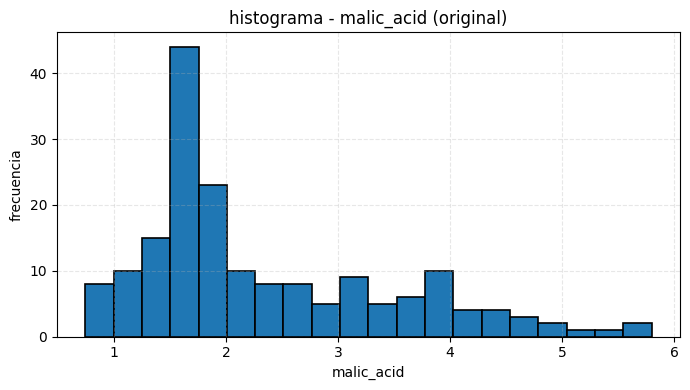

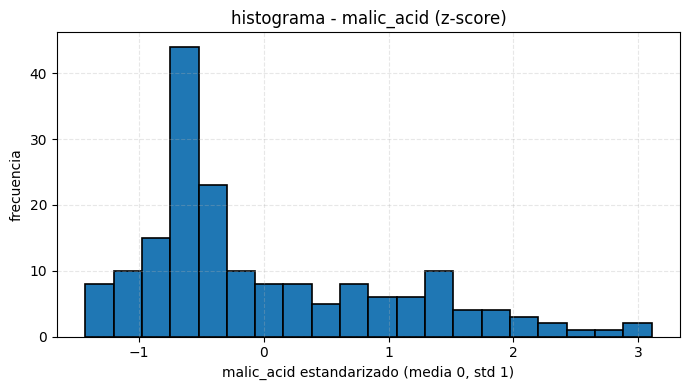

In [26]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from scipy.stats import shapiro
import numpy as np
import matplotlib.pyplot as plt

# Cargo el dataset wine como DataFrame para poder ver columnas por nombre
datos_wine = load_wine(as_frame=True)
X = datos_wine.data   # solo caracteristicas
y = datos_wine.target # no lo uso aqui, solo lo dejo por referencia

# Muestro las columnas para decidir que variable quiero analizar
print("Columnas disponibles:", list(X.columns))

# Elijo la caracteristica numerica a analizar
columna_objetivo = "malic_acid"
x = X[columna_objetivo].to_numpy()  # lo paso a vector 1D

# Corro la prueba de normalidad (Shapiro-Wilk) en los datos originales
# H0: los datos provienen de una distribucion normal; si p < 0.05, rechazo H0
W_original, p_original = shapiro(x)

# Aplico normalizacion Z-Score: (x - media) / desv_estandar
# Esta transformacion es lineal (afin): centra en 0 y lleva la desviacion a ~1
scaler = StandardScaler()
x_z = scaler.fit_transform(x.reshape(-1, 1)).ravel()

# Corro Shapiro-Wilk en los datos ya estandarizados
W_z, p_z = shapiro(x_z)

# Funcion corta para interpretar el p-valor
def interpreta_p(p):
    return "Rechazo normalidad (p < 0.05)" if p < 0.05 else "No rechazo normalidad (p >= 0.05)"

# Imprimo un resumen numerico
print("\n=== Resumen numerico ===")
print(f"Columna analizada: {columna_objetivo}")
print(f"Original -> min: {x.min():.4f}, max: {x.max():.4f}, media: {x.mean():.4f}, std: {x.std(ddof=0):.4f}")
print(f"Z-Score  -> min: {x_z.min():.4f}, max: {x_z.max():.4f}, media: {x_z.mean():.4f}, std: {x_z.std(ddof=0):.4f}")
print(f"Shapiro original -> W: {W_original:.6f}, p-valor: {p_original:.6f} -> {interpreta_p(p_original)}")
print(f"Shapiro Z-Score  -> W: {W_z:.6f}, p-valor: {p_z:.6f} -> {interpreta_p(p_z)}")

print("\nNota rapida:")
print("- Z-Score centra los datos en 0 y ajusta la desviacion a ~1, pero no cambia la forma de la distribucion.")
print("- Al ser una transformacion lineal, Shapiro tiende a dar el mismo W y p (salvo redondeos).")
print("- Estandarizar no vuelve normal a la variable si no lo era.")

# Grafico histogramas con borde en las barras y rejilla suave
plt.figure(figsize=(7, 4))
plt.hist(x, bins=20, edgecolor='black', linewidth=1.2)
plt.title(f'histograma - {columna_objetivo} (original)')
plt.xlabel(columna_objetivo)
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(x_z, bins=20, edgecolor='black', linewidth=1.2)
plt.title(f'histograma - {columna_objetivo} (z-score)')
plt.xlabel(f'{columna_objetivo} estandarizado (media 0, std 1)')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Respuestas: Z-Score y normalidad


## *1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?*


Al aplicar Z-Score, transformo cada valor restando la media y dividiendo entre la desviacion estandar. Esta operacion es lineal, por lo que **no altera la forma de la distribucion**: se conserva el orden de los datos, asi como su asimetria y curtosis. Lo que si cambia es la **escala**: la serie queda **centrada en 0** y con **desviacion estandar cercana a 1**; por tanto, los valores extremos pasan a representarse como puntuaciones altas en valor absoluto (por ejemplo, |z| > 2 o 3).

## 2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?

Respecto al test de normalidad, como Z-Score es una transformacion lineal, el estadistico de Shapiro–Wilk y su p-valor **permanecen practicamente iguales** antes y despues de estandarizar.
Si el p-valor es menor que 0.05, **rechazo la hipotesis de normalidad** tanto en la version original como en la estandarizada.

En conclusion la transformacion **no vuelve normal** a la variable y puede ser **sensible a outliers** porque usa la media y la desviacion estandar.


# **Ejercicio 3: Transformación Logarítmica**
Instrucciones:

1.	Cargar un conjunto de datos aleatorios generados con numpy.

2.	Aplicar una transformación logarítmica (np.log) a los datos.

3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

4.	Graficar los datos originales y transformados utilizando matplotlib.

5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación logarítmica a la distribución de los datos?

2.	¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


=== Resumen numerico ===
Original    -> min: 0.1942, max: 22.2681, media: 3.7831, std: 3.1511
Logaritmo   -> min: -1.6386, max: 3.1032, media: 1.0291, std: 0.8016
Shapiro original  -> W: 0.808252, p-valor: 0.000000 -> Rechazo normalidad (p < 0.05)
Shapiro log       -> W: 0.994046, p-valor: 0.119807 -> No rechazo normalidad (p >= 0.05)

Nota rapida:
- La transformacion logaritmica comprime valores grandes y expande valores pequenos (siempre positivos).
- En datos lognormales suele acercar la distribucion a algo mas simetrico/normal.
- El p-valor de Shapiro puede aumentar despues del log si efectivamente nos acercamos a la normalidad.


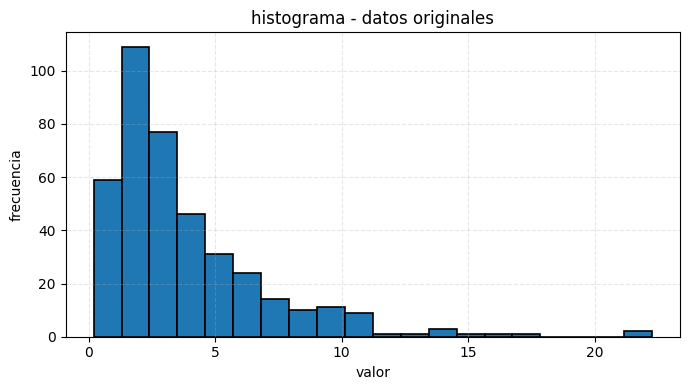

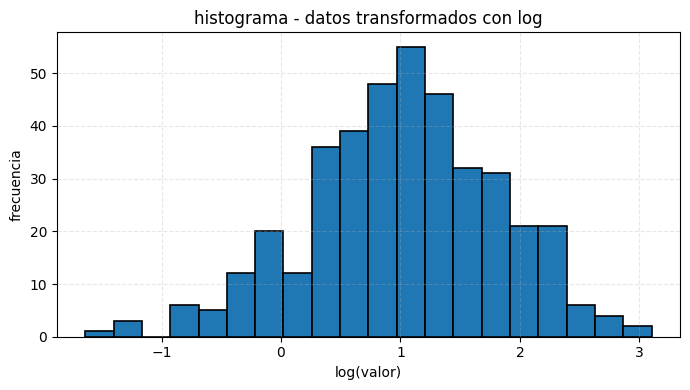

In [27]:
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt

# Fijo una semilla para que los resultados sean reproducibles
rng = np.random.default_rng(123)

# Genero un conjunto de datos positivos y sesgados a la derecha
# Uso una lognormal, porque su logaritmo es aproximadamente normal
tamano = 400
datos = rng.lognormal(mean=1.0, sigma=0.8, size=tamano)

# Verifico que todos sean > 0 para poder aplicar log sin problemas
assert np.all(datos > 0), "Los datos deben ser positivos para usar np.log."

# Calculo la version transformada con log natural
datos_log = np.log(datos)

# Prueba de normalidad (Shapiro-Wilk) en originales y transformados
W_orig, p_orig = shapiro(datos)
W_log , p_log  = shapiro(datos_log)

# Funcion auxiliar para interpretar p-valor
def interpreta_p(p):
    return "Rechazo normalidad (p < 0.05)" if p < 0.05 else "No rechazo normalidad (p >= 0.05)"

# Resumen numerico
print("=== Resumen numerico ===")
print(f"Original    -> min: {datos.min():.4f}, max: {datos.max():.4f}, media: {datos.mean():.4f}, std: {datos.std(ddof=0):.4f}")
print(f"Logaritmo   -> min: {datos_log.min():.4f}, max: {datos_log.max():.4f}, media: {datos_log.mean():.4f}, std: {datos_log.std(ddof=0):.4f}")
print(f"Shapiro original  -> W: {W_orig:.6f}, p-valor: {p_orig:.6f} -> {interpreta_p(p_orig)}")
print(f"Shapiro log       -> W: {W_log:.6f}, p-valor: {p_log:.6f} -> {interpreta_p(p_log)}")

print("\nNota rapida:")
print("- La transformacion logaritmica comprime valores grandes y expande valores pequenos (siempre positivos).")
print("- En datos lognormales suele acercar la distribucion a algo mas simetrico/normal.")
print("- El p-valor de Shapiro puede aumentar despues del log si efectivamente nos acercamos a la normalidad.")

# Graficos: histogramas con borde y rejilla suave
plt.figure(figsize=(7, 4))
plt.hist(datos, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos originales')
plt.xlabel('valor')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(datos_log, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos transformados con log')
plt.xlabel('log(valor)')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Respuestas: Transformación Logarítmica

## *1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?*

La transformacion logaritmica reduce el sesgo a la derecha al **comprimir los valores grandes** y **expandir los pequenos** por lo que el histograma se ve menos sesgado y con colas mas cortas en el extremo derecho.
En terminos de escala, los cambios relativos se vuelven mas comparables.

## *2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?*

Respecto al p-valor de la prueba de Shapiro–Wilk, si los datos originales estaban alejados de la normalidad por un sesgo fuerte, **despues del log el p-valor suele aumentar** y cruzar el umbral de 0.05, lo que implica que **ya no rechazo la normalidad** como sucedio en este ejemplo, antes se rechazo la normalidad y despues de la transforamcion ya no se rechazo la normalidad.


# **Ejercicio 4: Transformación Raíz Cuadrada**
Instrucciones:

1.	Cargar un conjunto de datos aleatorios generados con numpy.

2.	Aplicar una transformación de raíz cuadrada a los datos.

3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

4.	Graficar los datos originales y transformados utilizando matplotlib.

5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?

2.	¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


=== Resumen numerico ===
Original   -> min: 0.0612, max: 15.5278, media: 4.0331, std: 2.6969
Raiz sqrt  -> min: 0.2473, max: 3.9405, media: 1.8934, std: 0.6693
Shapiro original -> W: 0.926527, p-valor: 0.000000 -> Rechazo normalidad (p < 0.05)
Shapiro sqrt     -> W: 0.992364, p-valor: 0.011670 -> Rechazo normalidad (p < 0.05)

Nota rapida:
- La raiz cuadrada comprime valores grandes y suaviza el sesgo a la derecha.
- Puede acercar la distribucion a la normalidad, pero no lo garantiza en todos los casos.
- Es comun como estabilizador de varianza en datos de conteo o positivos.


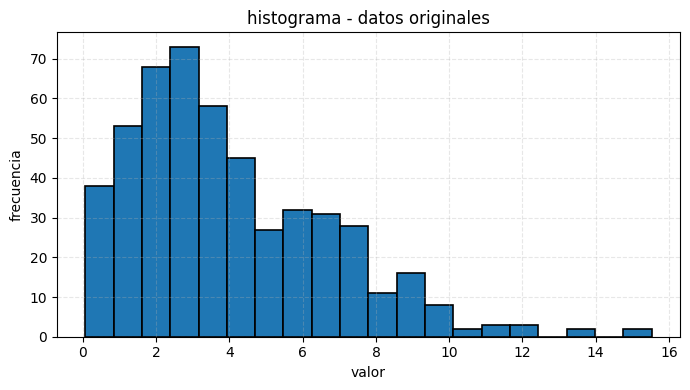

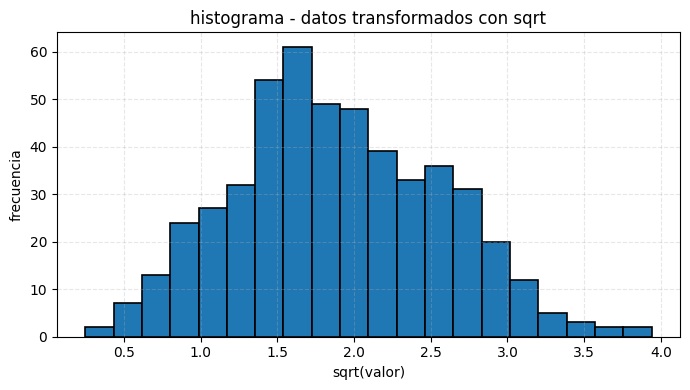

In [28]:
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt

# Fijo semilla para reproducibilidad
rng = np.random.default_rng(123)

# Genero un conjunto de datos positivos y con sesgo a la derecha
# Uso distribucion Gamma para tener valores > 0 y asimetria positiva
tamano = 500
datos = rng.gamma(shape=2.0, scale=2.0, size=tamano)

# Verifico que todo sea no negativo para poder aplicar sqrt sin problemas
assert np.all(datos >= 0), "Los datos deben ser no negativos para usar np.sqrt."

# Aplico la transformacion de raiz cuadrada
datos_sqrt = np.sqrt(datos)

# Pruebas de normalidad (Shapiro-Wilk) en originales y transformados
W_orig, p_orig = shapiro(datos)
W_sqrt, p_sqrt = shapiro(datos_sqrt)

# Funcion auxiliar para interpretar p-valor
def interpreta_p(p):
    return "Rechazo normalidad (p < 0.05)" if p < 0.05 else "No rechazo normalidad (p >= 0.05)"

# Resumen numerico
print("=== Resumen numerico ===")
print(f"Original   -> min: {datos.min():.4f}, max: {datos.max():.4f}, media: {datos.mean():.4f}, std: {datos.std(ddof=0):.4f}")
print(f"Raiz sqrt  -> min: {datos_sqrt.min():.4f}, max: {datos_sqrt.max():.4f}, media: {datos_sqrt.mean():.4f}, std: {datos_sqrt.std(ddof=0):.4f}")
print(f"Shapiro original -> W: {W_orig:.6f}, p-valor: {p_orig:.6f} -> {interpreta_p(p_orig)}")
print(f"Shapiro sqrt     -> W: {W_sqrt:.6f}, p-valor: {p_sqrt:.6f} -> {interpreta_p(p_sqrt)}")

print("\nNota rapida:")
print("- La raiz cuadrada comprime valores grandes y suaviza el sesgo a la derecha.")
print("- Puede acercar la distribucion a la normalidad, pero no lo garantiza en todos los casos.")
print("- Es comun como estabilizador de varianza en datos de conteo o positivos.")

# Graficos: histogramas con borde y rejilla suave
plt.figure(figsize=(7, 4))
plt.hist(datos, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos originales')
plt.xlabel('valor')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(datos_sqrt, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos transformados con sqrt')
plt.xlabel('sqrt(valor)')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Respuestas: Transformacion Raiz Cuadrada

## *1. Como afecto la transformacion raiz cuadrada a la distribucion de los datos?*

La transformacion de raiz cuadrada **redujo el sesgo a la derecha** al **comprimir los valores grandes** y acercarlos al cuerpo central de la distribucion. El histograma se hizo **mas simetrico** y con **colas menos pesadas** que el original.

## *2. Que efectos tuvo en el p-valor antes y despues de la transformacion?*

El **p-valor de Shapiro–Wilk aumento de ~6.28e-15 (original)** a **~0.0117 (sqrt)**, es decir, hubo **una mejora notable en la adecuacion a la normalidad**, coherente con la reduccion de sesgo. Sin embargo, como **0.0117 < 0.05**, **aun rechazo la normalidad** despues de la transformacion; en otras palabras, la raiz cuadrada **ayudo**, pero **no fue suficiente** para cumplir el criterio de normalidad al 5%.

# **Ejercicio 5: Transformación Box-Cox**
Instrucciones:

1.	Cargar un conjunto de datos aleatorios generados con numpy.

2.	Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.

3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

4.	Graficar los datos originales y transformados utilizando matplotlib.

5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación Box-Cox a la distribución de los datos?

2.	¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


=== Resumen numerico ===
n: 500
Original  -> min: 0.0612, max: 15.5278, media: 4.0331, std: 2.6969
Box-Cox   -> min: -1.7644, max: 4.6688, media: 1.5606, std: 1.1317
lambda Box-Cox: 0.3588
Shapiro original -> W: 0.926527, p-valor: 6.28216e-15 -> Rechazo normalidad (p < 0.05)
Shapiro Box-Cox  -> W: 0.996600, p-valor: 0.373532  -> No rechazo normalidad (p >= 0.05)

Nota rapida:
- Box-Cox intenta reducir el sesgo y estabilizar la varianza buscando aproximar la normalidad.
- Si lambda ~ 1, el efecto es parecido a identidad; si lambda ~ 0, se parece a log; si lambda ~ 0.5, a raiz cuadrada.
- En datos muy sesgados, Box-Cox suele subir el p-valor de Shapiro (mejor ajuste), pero no siempre alcanza p >= 0.05.


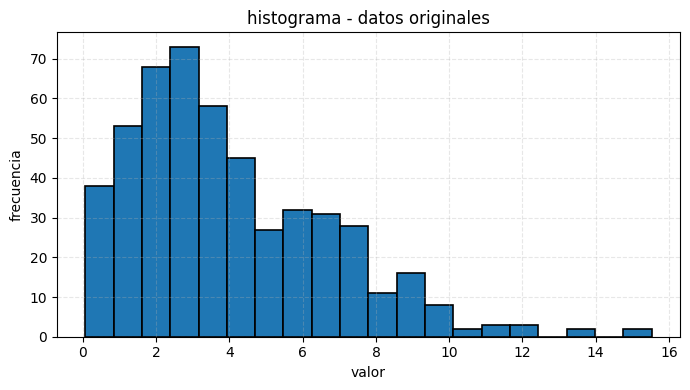

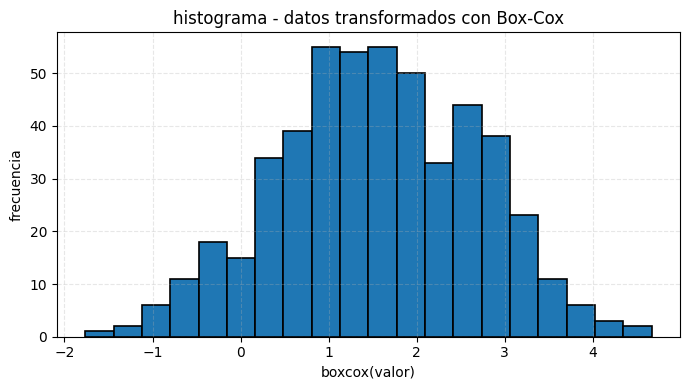

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, boxcox

# Fijo semilla para reproducibilidad
rng = np.random.default_rng(123)

# Genero datos positivos con sesgo a la derecha
# Uso una distribucion Gamma (siempre > 0), adecuada para aplicar Box-Cox
tamano = 500
datos = rng.gamma(shape=2.0, scale=2.0, size=tamano)

# Verifico positividad (Box-Cox requiere x > 0)
assert np.all(datos > 0), "Box-Cox requiere datos estrictamente positivos."

# Aplico la transformacion Box-Cox; guardo la lambda estimada por max verosimilitud
datos_bc, lam = boxcox(datos)

# Pruebas de normalidad (Shapiro-Wilk) en originales y transformados
W_orig, p_orig = shapiro(datos)
W_bc , p_bc  = shapiro(datos_bc)

# Funcion corta para interpretar el p-valor
def interpreta_p(p):
    return "Rechazo normalidad (p < 0.05)" if p < 0.05 else "No rechazo normalidad (p >= 0.05)"

# Resumen numerico e interpretacion
print("=== Resumen numerico ===")
print(f"n: {tamano}")
print(f"Original  -> min: {datos.min():.4f}, max: {datos.max():.4f}, media: {datos.mean():.4f}, std: {datos.std(ddof=0):.4f}")
print(f"Box-Cox   -> min: {datos_bc.min():.4f}, max: {datos_bc.max():.4f}, media: {datos_bc.mean():.4f}, std: {datos_bc.std(ddof=0):.4f}")
print(f"lambda Box-Cox: {lam:.4f}")
print(f"Shapiro original -> W: {W_orig:.6f}, p-valor: {p_orig:.6g} -> {interpreta_p(p_orig)}")
print(f"Shapiro Box-Cox  -> W: {W_bc:.6f}, p-valor: {p_bc:.6g}  -> {interpreta_p(p_bc)}")

print("\nNota rapida:")
print("- Box-Cox intenta reducir el sesgo y estabilizar la varianza buscando aproximar la normalidad.")
print("- Si lambda ~ 1, el efecto es parecido a identidad; si lambda ~ 0, se parece a log; si lambda ~ 0.5, a raiz cuadrada.")
print("- En datos muy sesgados, Box-Cox suele subir el p-valor de Shapiro (mejor ajuste), pero no siempre alcanza p >= 0.05.")

# Graficos: histogramas con borde y rejilla suave (no especifico color de relleno)
plt.figure(figsize=(7, 4))
plt.hist(datos, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos originales')
plt.xlabel('valor')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(datos_bc, bins=20, edgecolor='black', linewidth=1.2)
plt.title('histograma - datos transformados con Box-Cox')
plt.xlabel('boxcox(valor)')
plt.ylabel('frecuencia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Respuestas: Transformacion Box-Cox

## *1. Como afecto la transformacion Box-Cox a la distribucion de los datos?*

La transformacion Box-Cox **redujo el sesgo a la derecha** y **estabilizo la varianza**.

En el histograma, la forma luce **mas simetrica** y con **colas menos pesadas** que en los datos originales, lo que suele traducirse en un **p-valor de Shapiro mas alto** y, por tanto, en una mejor aproximacion a la normalidad.

El **p-value de Shapiro-Wilk** paso de **~6.28e-15** en los datos originales (rechazo claro de normalidad) a **~0.3735** despues de aplicar Box-Cox, lo cual **supera 0.05**. Por tanto, **ya no rechazo la normalidad** tras la transformacion. Esto es, que la transformacion logro alcanzar la normalidad en lso datos, fue efectiva.


## *2. Que interpretacion tiene el valor lambda obtenido en la transformacion Box-Cox?*

El parametro **lambda** es estimado por **maxima verosimilitud** para acercar los datos a la normalidad y **estabilizar la varianza**. Su valor describe el tipo de reescalado:
- **lambda ~ 1**: efecto cercano a la identidad (pocos cambios).
- **lambda ~ 0**: comportamiento parecido a una **transformacion logaritmica**.
- **lambda ~ 0.5**: efecto similar a **raiz cuadrada**.
- **lambda < 0**: compresion aun mas fuerte de colas derechas.

En resumen, **lambda indica cuanta y que clase de transformacion** se aplico para mejorar la simetria y la homocedasticidad en datos **estrictamente positivos**.
